In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [3]:
import os
for root, dirs, files in os.walk("./casia_dataset"):
    print(root)

./casia_dataset
./casia_dataset\casia
./casia_dataset\casia\CASIA1
./casia_dataset\casia\CASIA1\Au
./casia_dataset\casia\CASIA1\Sp
./casia_dataset\casia\CASIA2
./casia_dataset\casia\CASIA2\Au
./casia_dataset\casia\CASIA2\Tp
./casia_dataset\CASIA1
./casia_dataset\CASIA1\Au
./casia_dataset\CASIA1\Sp
./casia_dataset\CASIA2
./casia_dataset\CASIA2\Au
./casia_dataset\CASIA2\Tp


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import kaggle

DATASET_NAME = "sophatvathana/casia-dataset"
DOWNLOAD_DIR = "./casia_dataset"

# ── 1. DOWNLOAD ONLY IF NOT ALREADY DOWNLOADED ──────────────
if not os.path.exists("./casia_dataset/CASIA2/Au"):
    print("Downloading CASIA dataset from Kaggle...")
    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(DATASET_NAME, path=DOWNLOAD_DIR, unzip=True)
    print("Download complete!")
else:
    print("Dataset already exists, skipping download!")

# ── 2. SET PATHS ─────────────────────────────────────────────
REAL_DIR = "./casia_dataset/CASIA2/Au"
FAKE_DIR = "./casia_dataset/CASIA2/Tp"

# ── 3. LOAD IMAGES ───────────────────────────────────────────
IMG_SIZE = (128, 128)
SUPPORTED = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')

def load_images_from_folder(folder, label, img_size=IMG_SIZE):
    images, labels = [], []
    files = [f for f in os.listdir(folder) if f.lower().endswith(SUPPORTED)]
    print(f"\nLoading {len(files)} images from: {folder}")
    for i, fname in enumerate(files):
        try:
            img = Image.open(os.path.join(folder, fname)).convert("RGB")
            img = img.resize(img_size)
            images.append(np.array(img))
            labels.append(label)
        except Exception as e:
            print(f"  Skipping {fname}: {e}")
        if (i + 1) % 500 == 0:
            print(f"  Loaded {i + 1}/{len(files)}...")
    return np.array(images), np.array(labels)

X_real, y_real = load_images_from_folder(REAL_DIR, label=0)
X_fake, y_fake = load_images_from_folder(FAKE_DIR, label=1)

# ── 4. COMBINE & NORMALIZE ───────────────────────────────────
X = np.concatenate([X_real, X_fake], axis=0)
y = np.concatenate([y_real, y_fake], axis=0)
X = X / 255.0

print(f"\nTotal images : {X.shape[0]}")
print(f"Real (0)     : {np.sum(y == 0)}")
print(f"Fake (1)     : {np.sum(y == 1)}")

Dataset already exists, skipping download!

Loading 7491 images from: ./casia_dataset/CASIA2/Au
  Loaded 500/7491...
  Loaded 1000/7491...
  Loaded 1500/7491...
  Loaded 2000/7491...
  Loaded 2500/7491...
  Loaded 3000/7491...
  Loaded 3500/7491...
  Loaded 4000/7491...
  Loaded 4500/7491...
  Loaded 5000/7491...
  Loaded 5500/7491...
  Loaded 6000/7491...
  Loaded 6500/7491...
  Loaded 7000/7491...

Loading 5123 images from: ./casia_dataset/CASIA2/Tp
  Loaded 500/5123...
  Loaded 1000/5123...
  Loaded 1500/5123...
  Loaded 2000/5123...
  Loaded 2500/5123...
  Loaded 3000/5123...
  Loaded 3500/5123...
  Loaded 4000/5123...
  Loaded 4500/5123...
  Loaded 5000/5123...

Total images : 12614
Real (0)     : 7491
Fake (1)     : 5123


In [5]:

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42
)

# Convert labels to categorical
y_train_cat = to_categorical(y_train, 2)
y_val_cat   = to_categorical(y_val, 2)
y_test_cat  = to_categorical(y_test, 2)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (9081, 128, 128, 3), Val: (1010, 128, 128, 3), Test: (2523, 128, 128, 3)


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data Augmentation — generates more variety from existing images
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# Improved CNN Model
model = Sequential([
    # Block 1
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.4),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(2, activation='softmax')  # softmax: works for binary too, keeps code consistent
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# EarlyStopping + ReduceLR for better convergence
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)

# Train with augmentation
history = model.fit(
    datagen.flow(X_train, y_train_cat, batch_size=32),
    validation_data=(X_val, y_val_cat),
    epochs=30,
    callbacks=[early_stop, reduce_lr]
)

d:\MachineLearning\myvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,068,706 (65.11 MB)

 Trainable params: 17,067,234 (65.11 MB)

 Non-trainable params: 1,472 (5.75 KB)

Epoch 1/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 201s 684ms/step - accuracy: 0.5855 - loss: 0.7985 - val_accuracy: 0.6010 - val_loss: 0.6785 - learning_rate: 0.0010
Epoch 2/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 179s 628ms/step - accuracy: 0.6008 - loss: 0.7007 - val_accuracy: 0.6356 - val_loss: 0.6458 - learning_rate: 0.0010
Epoch 3/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 166s 583ms/step - accuracy: 0.6213 - loss: 0.6591 - val_accuracy: 0.6455 - val_loss: 0.6364 - learning_rate: 0.0010
Epoch 4/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 163s 573ms/step - accuracy: 0.6369 - loss: 0.6480 - val_accuracy: 0.6406 - val_loss: 0.6414 - learning_rate: 0.0010
Epoch 5/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 161s 568ms/step - accuracy: 0.6343 - loss: 0.6478 - val_accuracy: 0.5218 - val_loss: 0.9512 - learning_rate: 0.0010
Epoch 6/30
284/284 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.6264 - loss: 0.6530
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
284/284 ━━━━━━━━━━━━━━━━━━━━ 160s 562ms/step - accuracy:

79/79 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step
── Classification Report ──
              precision    recall  f1-score   support

        Real       0.88      0.79      0.83      1498
        Fake       0.73      0.84      0.79      1025

    accuracy                           0.81      2523
   macro avg       0.81      0.82      0.81      2523
weighted avg       0.82      0.81      0.81      2523



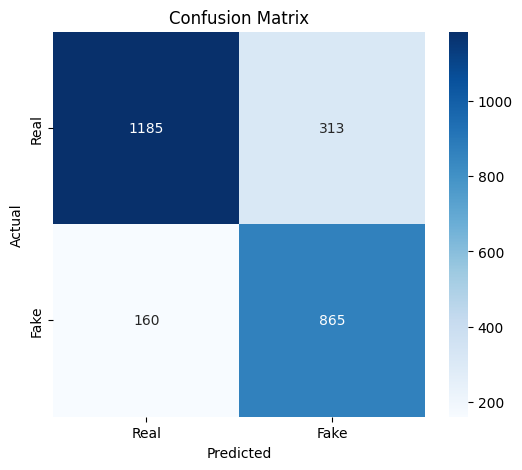


── Model Performance Summary ──
              Model  Accuracy  Precision  Recall  F1-Score
CNN (Deep Learning)    0.8125     0.7343  0.8439    0.7853


In [7]:
from sklearn.metrics import classification_report, confusion_matrix  #maxpooling, dropout, batchnorm, earlystopping poosible ways to improve model 
import seaborn as sns

# Get predictions
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

# Classification Report (like your professor's example)
print("── Classification Report ──")
print(classification_report(y_true, y_pred, target_names=["Real", "Fake"]))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])
plt.title("Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.savefig("confusion_matrix.png")
plt.show()

# Summary table (like professor's comparison table)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = pd.DataFrame([{
    "Model": "CNN (Deep Learning)",
    "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
    "Precision": round(precision_score(y_true, y_pred), 4),
    "Recall":    round(recall_score(y_true, y_pred), 4),
    "F1-Score":  round(f1_score(y_true, y_pred), 4)
}])
print("\n── Model Performance Summary ──")
print(results.to_string(index=False))

In [7]:
model.save("casia_model.h5")
print("Model saved!", os.path.abspath("casia_model.h5"))

Model saved! d:\MachineLearning\casia_model.h5


In [9]:
model.save('casia_model.keras')
print("Saved!", os.path.abspath('casia_model.keras'))

Saved! d:\MachineLearning\casia_model.keras


d:\MachineLearning\myvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Saved! d:\MachineLearning\casia_model_fixed.keras


In [11]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# Rebuild clean architecture
new_model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    Conv2D(32,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),
    Conv2D(64,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.25),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128,(3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2), Dropout(0.4),
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(), Dropout(0.5),
    Dense(2, activation='softmax')
])

new_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Transfer weights from old trained model
new_model.set_weights(model.get_weights())

# Save in clean format
new_model.save('casia_model.keras')
print("Done!", os.path.abspath('casia_model.keras'))

Done! d:\MachineLearning\casia_model.keras
